# NFRKB perturbation effect size check

This notebook inspects `merged.h5ad` and compares the perturbation effect for `NFRKB` against other perturbed genes in the dataset. The requested label `NFKRB` is not present in this AnnData object; the present perturbation label is `NFRKB`, with 4,848 cells.

The comparisons below use dataset-matched controls: each perturbation mean is compared with control cells from the same `dataset`, then per-dataset deltas are summarized across matched datasets.


In [1]:
from pathlib import Path
import sys

expected_python = Path('/projects/b1042/GoyalLab/jaekj/python/KS_perturb/bin/python')
h5ad_path = Path('/projects/b1042/GoyalLab/jaekj/KeepingScore/perturb-seq/ExPert/anndata/merged.h5ad')

print('Python:', sys.executable)
print('Expected:', expected_python)
assert Path(sys.executable).resolve() == expected_python.resolve(), (
    f'Please run this notebook with {expected_python}; current kernel is {sys.executable}'
)
assert h5ad_path.exists(), h5ad_path


Python: /projects/b1042/GoyalLab/jaekj/python/KS_perturb/bin/python
Expected: /projects/b1042/GoyalLab/jaekj/python/KS_perturb/bin/python


In [2]:
import anndata as ad
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 120)
pd.set_option('display.max_columns', 80)
plt.rcParams['figure.dpi'] = 120

adata = ad.read_h5ad(h5ad_path, backed='r')
adata


AnnData object with n_obs × n_vars = 197249 × 13992 backed at '/projects/b1042/GoyalLab/jaekj/KeepingScore/perturb-seq/ExPert/anndata/merged.h5ad'
    obs: 'perturbation', 'efficiency', 'dataset', 'eff_score', 'perturbation_type', 'cls_label', 'split'
    obsm: 'ExPert_latent_z_shared'

In [3]:
print('shape:', adata.shape)
print('obs columns:', list(adata.obs.columns))
print('var columns:', list(adata.var.columns))
print('layers:', list(adata.layers.keys()))
print('obsm:', {k: adata.obsm[k].shape for k in adata.obsm.keys()})
print('X:', type(adata.X), getattr(adata.X, 'dtype', None))

display(adata.obs.head())
display(adata.obs['perturbation'].value_counts().head(25).to_frame('n_cells'))
display(adata.obs['dataset'].value_counts().to_frame('n_cells'))


shape: (197249, 13992)
obs columns: ['perturbation', 'efficiency', 'dataset', 'eff_score', 'perturbation_type', 'cls_label', 'split']
var columns: []
layers: []
obsm: {'ExPert_latent_z_shared': (197249, 384)}
X: <class 'anndata._core.sparse_dataset._CSRDataset'> float64


,perturbation,efficiency,dataset,eff_score,perturbation_type,cls_label,split
AAACCAATCATTAGTCAACGGGAA-1_CD4i_R1L08_CD4i_R1_D1_Rest_CD4i_R1_Ultima;Marson2025_D1_Rest,EIF1,1.530678,Marson2025_D1_Rest,1.527950,CRISPRi,EIF1,train
AAAGTCATCGCGTTACACTTTAGG-1_CD4i_R1L08_CD4i_R1_D1_Rest_CD4i_R1_Ultima;Marson2025_D1_Rest,PSMB5,2.852200,Marson2025_D1_Rest,2.834641,CRISPRi,PSMB5,val
AACCAACAGAGCAACTAACGGGAA-1_CD4i_R1L08_CD4i_R1_D1_Rest_CD4i_R1_Ultima;Marson2025_D1_Rest,ANKRD11,-0.138770,Marson2025_D1_Rest,0.138768,CRISPRi,ANKRD11,val
AACCCGGCAATGTTCCACTTTAGG-1_CD4i_R1L08_CD4i_R1_D1_Rest_CD4i_R1_Ultima;Marson2025_D1_Rest,PTMA,3.128171,Marson2025_D1_Rest,3.105041,CRISPRi,PTMA,train
AAGACAACACTATCACATGTTGAC-1_CD4i_R1L08_CD4i_R1_D1_Rest_CD4i_R1_Ultima;Marson2025_D1_Rest,PTMA,2.286528,Marson2025_D1_Rest,2.277457,CRISPRi,PTMA,train


,n_cells
perturbation,
control,19000
SETDB1,12149
GFM1,6039
NFRKB,4848
ANKRD11,3918
MRPL36,3814
TFAM,3627
MED19,3549
JAZF1,3363


,n_cells
dataset,
ReplogleWeissman2022_K562_gwps,23481
XAtlas2025_HEK293T,22500
ReplogleWeissman2025_Jurkat,22016
ReplogleWeissman2022_rpe1,20331
ReplogleWeissman2022_K562_essential,18170
XAtlas2025_HCT116,15716
ReplogleWeissman2025_HepG2,10875
Marson2025_D3_Rest,7000
Marson2025_D2_Stim8hr,6447


In [4]:
requested_target = 'NFKRB'
target = requested_target
perturbations = pd.Index(adata.obs['perturbation'].astype(str).unique())
var_names = pd.Index(adata.var_names.astype(str))

print('Requested target:', requested_target)
print('Requested target in perturbations:', requested_target in set(perturbations))
print('Requested target in var_names:', requested_target in set(var_names))

if requested_target not in set(perturbations) and 'NFRKB' in set(perturbations):
    target = 'NFRKB'
    print('Using target = NFRKB because NFKRB is absent and NFRKB is present.')

print('target:', target)
print('target perturbation cells:', int((adata.obs['perturbation'].astype(str) == target).sum()))
print('target measured gene in var_names:', target in set(var_names))
print('NFK/NFR-like measured genes:', [g for g in var_names if ('NFK' in g or 'NFR' in g)][:80])

display(adata.obs.loc[adata.obs['perturbation'].astype(str).eq(target), 'dataset'].value_counts().to_frame('target_cells'))
display(adata.obs.loc[adata.obs['perturbation'].astype(str).eq('control'), 'dataset'].value_counts().to_frame('control_cells'))


Requested target: NFKRB
Requested target in perturbations: False
Requested target in var_names: False
Using target = NFRKB because NFKRB is absent and NFRKB is present.
target: NFRKB
target perturbation cells: 4848
target measured gene in var_names: False
NFK/NFR-like measured genes: ['NFKB1', 'NFKBIA', 'NFKBIB', 'NFKBIL1', 'TNFRSF10A', 'TNFRSF10B', 'TNFRSF12A', 'TNFRSF1A', 'NFKB2', 'NFKBIZ', 'TNFRSF10D', 'TNFRSF11A', 'NFKBIE', 'TNFRSF14', 'TNFRSF19', 'TNFRSF21', 'TNFRSF4', 'NFKBID', 'TNFRSF10C', 'TNFRSF11B', 'TNFRSF13B', 'TNFRSF17', 'TNFRSF18', 'TNFRSF1B', 'TNFRSF6B', 'TNFRSF8', 'TNFRSF9']


,target_cells
dataset,
Marson2025_D3_Rest,635
Marson2025_D3_Stim8hr,441
Marson2025_D3_Stim48hr,435
ReplogleWeissman2022_K562_gwps,421
Marson2025_D1_Rest,281
Marson2025_D1_Stim48hr,279
Marson2025_D2_Rest,250
Marson2025_D1_Stim8hr,245
Marson2025_D2_Stim8hr,236


,control_cells
dataset,
Marson2025_D1_Rest,1000
Marson2025_D1_Stim8hr,1000
Marson2025_D1_Stim48hr,1000
Marson2025_D2_Rest,1000
Marson2025_D2_Stim8hr,1000
Marson2025_D2_Stim48hr,1000
Marson2025_D3_Rest,1000
Marson2025_D3_Stim8hr,1000
Marson2025_D3_Stim48hr,1000


## Metric definitions

For each `(dataset, perturbation)` pair, the notebook computes:

- `delta = mean(perturbation cells) - mean(control cells from the same dataset)`
- `l2`: Euclidean norm of `delta`
- `rms_delta`: root mean squared delta across dimensions
- `mean_abs_delta`: mean absolute delta across dimensions
- `max_abs_delta`: largest absolute single-dimension delta

Then it aggregates those matched-dataset effects per perturbation with cell-count weights. The same logic is applied to both the ExPert latent space and the expression matrix.


In [5]:
obs = adata.obs.copy()
obs['perturbation'] = obs['perturbation'].astype(str)
obs['dataset'] = obs['dataset'].astype(str)

MIN_PERT_CELLS = 20
CONTROL_LABEL = 'control'

control_counts = obs.loc[obs['perturbation'].eq(CONTROL_LABEL)].groupby('dataset').size()
pert_counts = obs.groupby(['dataset', 'perturbation']).size().rename('n_cells').reset_index()
matched_groups = pert_counts.loc[
    pert_counts['dataset'].isin(control_counts.index)
    & ~pert_counts['perturbation'].eq(CONTROL_LABEL)
    & pert_counts['n_cells'].ge(MIN_PERT_CELLS)
].copy()

print('matched perturbation/dataset groups:', len(matched_groups))
print('perturbations with matched controls:', matched_groups['perturbation'].nunique())
display(matched_groups.sort_values(['perturbation', 'dataset']).head(20))


matched perturbation/dataset groups: 928
perturbations with matched controls: 97


,dataset,perturbation,n_cells
0,Marson2025_D1_Rest,ACTB,161
26,Marson2025_D1_Stim48hr,ACTB,243
52,Marson2025_D1_Stim8hr,ACTB,220
157,Marson2025_D3_Rest,ACTB,182
181,Marson2025_D3_Stim48hr,ACTB,180
204,Marson2025_D3_Stim8hr,ACTB,204
228,Marson2025_D4_Rest,ACTB,84
259,Marson2025_D4_Stim48hr,ACTB,117
291,Marson2025_D4_Stim8hr,ACTB,97
324,ReplogleWeissman2022_K562_essential,ACTB,160


In [6]:
def _as_1d_mean(x):
    m = x.mean(axis=0)
    if sp.issparse(m):
        m = m.A1
    else:
        m = np.asarray(m).ravel()
    return m.astype(np.float64, copy=False)

def summarize_delta(delta):
    delta = np.asarray(delta, dtype=np.float64)
    return {
        'l2': float(np.linalg.norm(delta)),
        'rms_delta': float(np.sqrt(np.mean(delta ** 2))),
        'mean_abs_delta': float(np.mean(np.abs(delta))),
        'max_abs_delta': float(np.max(np.abs(delta))),
    }

def aggregate_group_metrics(group_metrics):
    df = pd.DataFrame(group_metrics)
    metric_cols = ['l2', 'rms_delta', 'mean_abs_delta', 'max_abs_delta']
    out = df.groupby('perturbation').agg(
        n_cells=('n_cells', 'sum'),
        n_datasets=('dataset', 'nunique'),
    )
    for metric in metric_cols:
        out[metric] = df.groupby('perturbation').apply(
            lambda g, metric=metric: np.average(g[metric], weights=g['n_cells'])
        )
    return out.reset_index()

def add_target_ranks(summary, target):
    summary = summary.copy()
    for metric in ['l2', 'rms_delta', 'mean_abs_delta', 'max_abs_delta']:
        summary[f'{metric}_rank_desc'] = summary[metric].rank(ascending=False, method='min').astype(int)
    target_rows = summary.loc[summary['perturbation'].eq(target)]
    if target_rows.empty:
        print(f'{target} was not found in the summary.')
    else:
        target_row = target_rows.iloc[0]
        n = len(summary)
        print(f'{target} rank among {n} perturbations:')
        for metric in ['l2', 'rms_delta', 'mean_abs_delta', 'max_abs_delta']:
            print(f'  {metric}: rank {int(target_row[f"{metric}_rank_desc"])} / {n}, value {target_row[metric]:.6g}')
    return summary


## ExPert latent effect sizes

This is the quickest and usually most direct check for whether the learned ExPert representation moves more for `NFRKB` than for other perturbations.


In [7]:
latent_key = 'ExPert_latent_z_shared'
Z = np.asarray(adata.obsm[latent_key])

dataset_arr = obs['dataset'].to_numpy()
pert_arr = obs['perturbation'].to_numpy()
control_latent_mean = {
    dataset: Z[(dataset_arr == dataset) & (pert_arr == CONTROL_LABEL)].mean(axis=0)
    for dataset in control_counts.index
}

latent_group_metrics = []
for row in matched_groups.itertuples(index=False):
    idx = (dataset_arr == row.dataset) & (pert_arr == row.perturbation)
    delta = Z[idx].mean(axis=0) - control_latent_mean[row.dataset]
    latent_group_metrics.append({
        'dataset': row.dataset,
        'perturbation': row.perturbation,
        'n_cells': int(row.n_cells),
        **summarize_delta(delta),
    })

latent_summary = aggregate_group_metrics(latent_group_metrics)
latent_summary = add_target_ranks(latent_summary, target)
latent_summary.sort_values('l2', ascending=False).head(25)


NFRKB rank among 97 perturbations:
  l2: rank 1 / 97, value 32.4028
  rms_delta: rank 1 / 97, value 1.65355
  mean_abs_delta: rank 6 / 97, value 0.568441
  max_abs_delta: rank 5 / 97, value 8.29272


/tmp/ipykernel_2700168/3833835623.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out[metric] = df.groupby('perturbation').apply(
/tmp/ipykernel_2700168/3833835623.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out[metric] = df.groupby('perturbation').apply(
/tmp/ipykernel_2700168/3833835623.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a

,perturbation,n_cells,n_datasets,l2,rms_delta,mean_abs_delta,max_abs_delta,l2_rank_desc,rms_delta_rank_desc,mean_abs_delta_rank_desc,max_abs_delta_rank_desc
54,NFRKB,4848,19,32.402770,1.653547,0.568441,8.292720,1,1,6,5
73,SETDB1,12149,19,30.796551,1.571580,0.537698,7.976966,2,2,15,7
38,MED19,3549,18,29.797284,1.520586,0.547053,8.167521,3,3,11,6
13,DLD,1030,9,28.457136,1.452197,0.562197,7.887291,4,4,8,10
57,OGFOD1,967,7,27.803050,1.418818,0.587684,7.816922,5,5,3,12
21,EXOSC2,683,6,27.459702,1.401297,0.603877,7.838442,6,6,1,11
17,EIF1,1855,16,27.441911,1.400389,0.527837,6.980530,7,7,17,31
91,UPF2,1223,7,27.072618,1.381544,0.590975,7.299847,8,8,2,20
7,CNOT3,952,5,27.037026,1.379727,0.566410,7.767029,9,9,7,13
93,WTAP,3248,16,27.033543,1.379550,0.505469,6.783973,10,10,24,39


,perturbation,n_cells,n_datasets,l2,rms_delta,mean_abs_delta,max_abs_delta,l2_rank_desc,rms_delta_rank_desc,mean_abs_delta_rank_desc,max_abs_delta_rank_desc
54,NFRKB,4848,19,32.40277,1.653547,0.568441,8.29272,1,1,6,5


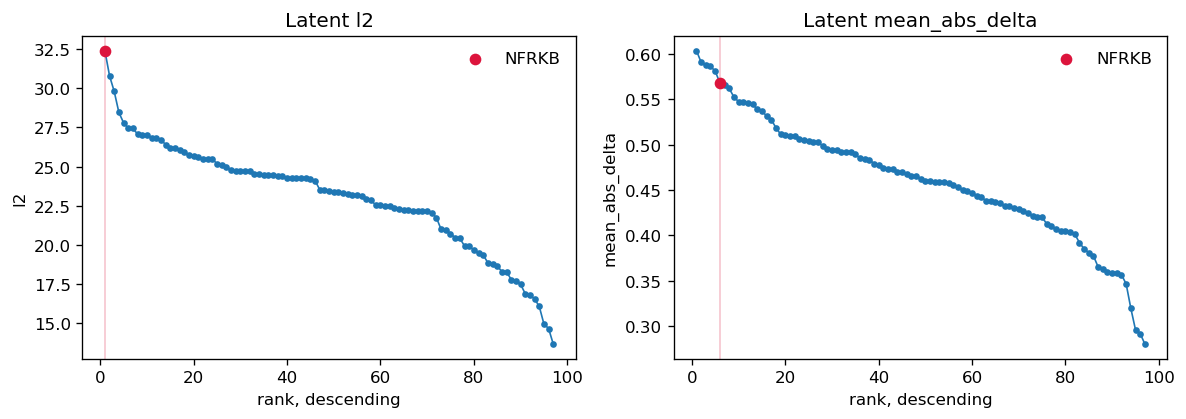

In [8]:
target_latent = latent_summary.loc[latent_summary['perturbation'].eq(target)]
display(target_latent)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, metric in zip(axes, ['l2', 'mean_abs_delta']):
    vals = latent_summary[metric].sort_values(ascending=False).reset_index(drop=True)
    ax.plot(np.arange(1, len(vals) + 1), vals, marker='.', linewidth=1)
    if not target_latent.empty:
        tval = float(target_latent[metric].iloc[0])
        trank = int(target_latent[f'{metric}_rank_desc'].iloc[0])
        ax.scatter([trank], [tval], color='crimson', zorder=5, label=target)
        ax.axvline(trank, color='crimson', alpha=0.25, linewidth=1)
    ax.set_title(f'Latent {metric}')
    ax.set_xlabel('rank, descending')
    ax.set_ylabel(metric)
    ax.legend(frameon=False)
plt.tight_layout()


## Expression effect sizes

This section computes pseudobulk expression differences versus matched controls. It may take longer than the latent comparison because it reads the backed sparse expression matrix for each perturbation/dataset group.


In [9]:
# Dataset-matched control means in expression space.
control_expr_mean = {}
for dataset in control_counts.index:
    idx = np.flatnonzero((dataset_arr == dataset) & (pert_arr == CONTROL_LABEL))
    control_expr_mean[dataset] = _as_1d_mean(adata.X[idx, :])

expr_group_metrics = []
for i, row in enumerate(matched_groups.itertuples(index=False), start=1):
    idx = np.flatnonzero((dataset_arr == row.dataset) & (pert_arr == row.perturbation))
    delta = _as_1d_mean(adata.X[idx, :]) - control_expr_mean[row.dataset]
    expr_group_metrics.append({
        'dataset': row.dataset,
        'perturbation': row.perturbation,
        'n_cells': int(row.n_cells),
        **summarize_delta(delta),
    })
    if i % 100 == 0 or i == len(matched_groups):
        print(f'processed {i} / {len(matched_groups)} groups')

expr_summary = aggregate_group_metrics(expr_group_metrics)
expr_summary = add_target_ranks(expr_summary, target)
expr_summary.sort_values('l2', ascending=False).head(25)


processed 100 / 928 groups
processed 200 / 928 groups
processed 300 / 928 groups
processed 400 / 928 groups
processed 500 / 928 groups
processed 600 / 928 groups
processed 700 / 928 groups
processed 800 / 928 groups
processed 900 / 928 groups
processed 928 / 928 groups
NFRKB rank among 97 perturbations:
  l2: rank 96 / 97, value 388.196
  rms_delta: rank 96 / 97, value 3.28179
  mean_abs_delta: rank 93 / 97, value 0.665927
  max_abs_delta: rank 94 / 97, value 171.43


/tmp/ipykernel_2700168/3833835623.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out[metric] = df.groupby('perturbation').apply(
/tmp/ipykernel_2700168/3833835623.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out[metric] = df.groupby('perturbation').apply(
/tmp/ipykernel_2700168/3833835623.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a

,perturbation,n_cells,n_datasets,l2,rms_delta,mean_abs_delta,max_abs_delta,l2_rank_desc,rms_delta_rank_desc,mean_abs_delta_rank_desc,max_abs_delta_rank_desc
9,CSE1L,966,5,724.680355,6.126418,0.838085,305.942905,1,1,35,1
56,NUP107,894,6,699.808603,5.916153,0.853265,289.357861,2,2,30,2
72,SART3,1197,7,691.119606,5.842696,0.880790,268.041546,3,3,14,12
21,EXOSC2,683,6,687.679343,5.813612,0.887147,280.050319,4,4,8,6
33,INTS8,825,6,686.929088,5.807270,0.795415,285.707144,5,5,56,5
62,PSMA4,1123,6,678.313440,5.734434,0.913614,269.874635,6,6,5,9
90,UBA2,720,5,675.598060,5.711478,0.749942,287.602146,7,7,74,4
19,EIF2B2,888,6,672.939165,5.689000,0.831240,275.876572,8,8,41,7
66,RABGGTA,1005,7,672.105115,5.681949,0.876406,258.351354,9,9,17,15
8,CPSF3,1489,6,672.004360,5.681097,0.766364,289.138678,10,10,67,3


,perturbation,n_cells,n_datasets,l2,rms_delta,mean_abs_delta,max_abs_delta,l2_rank_desc,rms_delta_rank_desc,mean_abs_delta_rank_desc,max_abs_delta_rank_desc
54,NFRKB,4848,19,388.19595,3.281792,0.665927,171.429646,96,96,93,94


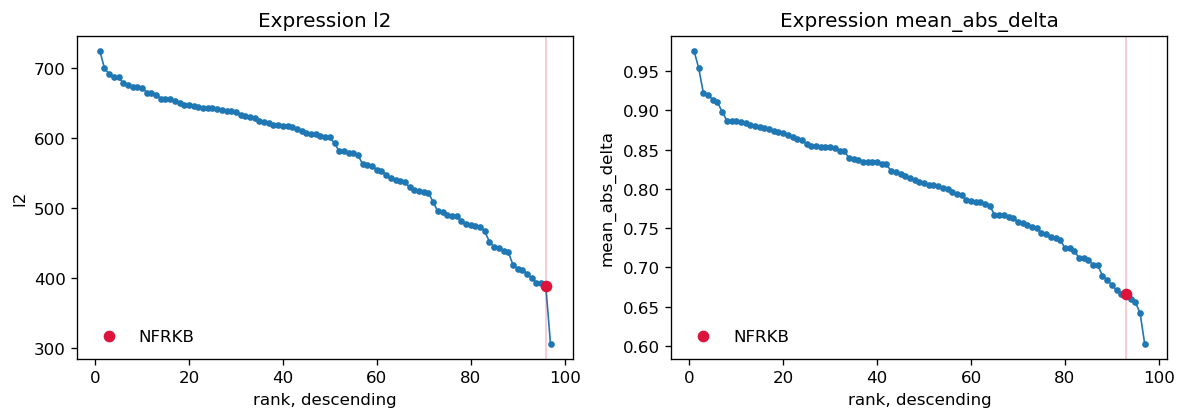

In [10]:
target_expr = expr_summary.loc[expr_summary['perturbation'].eq(target)]
display(target_expr)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, metric in zip(axes, ['l2', 'mean_abs_delta']):
    vals = expr_summary[metric].sort_values(ascending=False).reset_index(drop=True)
    ax.plot(np.arange(1, len(vals) + 1), vals, marker='.', linewidth=1)
    if not target_expr.empty:
        tval = float(target_expr[metric].iloc[0])
        trank = int(target_expr[f'{metric}_rank_desc'].iloc[0])
        ax.scatter([trank], [tval], color='crimson', zorder=5, label=target)
        ax.axvline(trank, color='crimson', alpha=0.25, linewidth=1)
    ax.set_title(f'Expression {metric}')
    ax.set_xlabel('rank, descending')
    ax.set_ylabel(metric)
    ax.legend(frameon=False)
plt.tight_layout()


## Genes contributing most to the NFRKB expression shift

The next cell pools the dataset-matched `NFRKB - control` deltas with cell-count weights and lists the genes with largest absolute changes.


In [11]:
target_group_rows = matched_groups.loc[matched_groups['perturbation'].eq(target)].copy()
if target_group_rows.empty:
    raise ValueError(f'No matched groups found for target {target}')

weighted_delta = np.zeros(adata.n_vars, dtype=np.float64)
total_weight = 0
for row in target_group_rows.itertuples(index=False):
    idx = np.flatnonzero((dataset_arr == row.dataset) & (pert_arr == target))
    delta = _as_1d_mean(adata.X[idx, :]) - control_expr_mean[row.dataset]
    weighted_delta += delta * row.n_cells
    total_weight += row.n_cells
weighted_delta /= total_weight

top_genes = pd.DataFrame({
    'gene': adata.var_names.astype(str),
    'weighted_delta': weighted_delta,
    'abs_delta': np.abs(weighted_delta),
}).sort_values('abs_delta', ascending=False)

display(top_genes.head(50))
if target in set(adata.var_names.astype(str)):
    display(top_genes.loc[top_genes['gene'].eq(target)])


,gene,weighted_delta,abs_delta
112,ACTB,-95.158510,95.158510
4779,TMSB4X,-91.417010,91.417010
2788,MT-CO3,-65.762106,65.762106
2787,MT-CO2,-63.603711,63.603711
2786,MT-CO1,-53.441178,53.441178
2784,MT-ATP6,-45.276219,45.276219
4778,TMSB10,-44.714822,44.714822
7202,IL32,-39.159589,39.159589
2793,MT-ND4,-35.106227,35.106227
3292,PFN1,-33.419665,33.419665


## Save result tables

The notebook writes CSV summaries next to this notebook so rankings can be reused without rerunning all cells.


In [12]:
# out_dir = h5ad_path.parent
# latent_csv = out_dir / 'pert_changes_latent_summary.csv'
# expr_csv = out_dir / 'pert_changes_expression_summary.csv'
# top_gene_csv = out_dir / f'pert_changes_{target}_top_expression_genes.csv'

# latent_summary.sort_values('l2', ascending=False).to_csv(latent_csv, index=False)
# expr_summary.sort_values('l2', ascending=False).to_csv(expr_csv, index=False)
# top_genes.to_csv(top_gene_csv, index=False)

# print(latent_csv)
# print(expr_csv)
# print(top_gene_csv)


In [13]:
adata.file.close()
